<a href="https://colab.research.google.com/github/opinner/thesis_introductory_figures/blob/main/WeddellSea_on_the_blue_marble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
! pip install cartopy --quiet

In [20]:
import matplotlib.pyplot as plt  # package for plotting
import cartopy.feature as cfeature  # package for making maps
import cartopy.crs as ccrs  # cartopy projections
from cartopy.geodesic import Geodesic
import PIL  # package for imaging manipulation
import urllib  # package for working with urls
import numpy as np

In [35]:
img_url = 'https://eoimages.gsfc.nasa.gov/images/imagerecords/73000/73605/world.topo.bathy.200402.3x5400x2700.jpg'

In [36]:
def plot_map(url, projection=ccrs.PlateCarree(), gridlines=False):
    # Load the image
    img = PIL.Image.open(urllib.request.urlopen(url))

    # Define the image (covers the entire Earth)
    img_extent = (-180, 180, -90, 90)

    ax = plt.axes(projection=projection)
    ax.set_global()
    if gridlines:
        ax.gridlines()

    ax.imshow(img, origin='upper', extent=img_extent, transform=ccrs.PlateCarree())

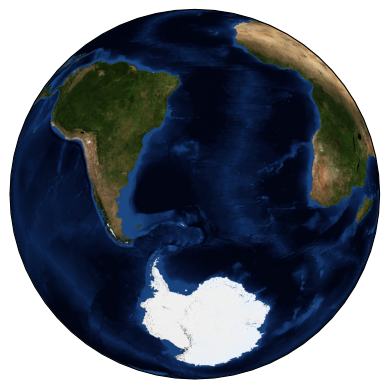

In [37]:
projection = ccrs.Orthographic(central_longitude=-30, central_latitude=-45)
plot_map(img_url, projection=projection) #, gridlines=True)

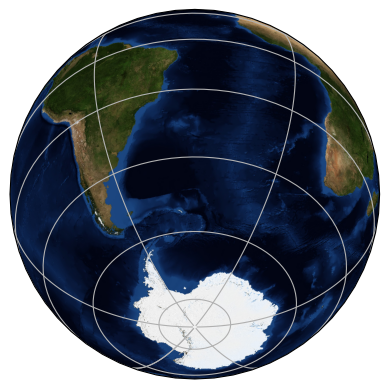

In [38]:
projection = ccrs.NearsidePerspective(central_longitude=-30, central_latitude=-50, satellite_height=35785831, false_easting=0, false_northing=0, globe=None)
plot_map(img_url, projection=projection, gridlines=True)

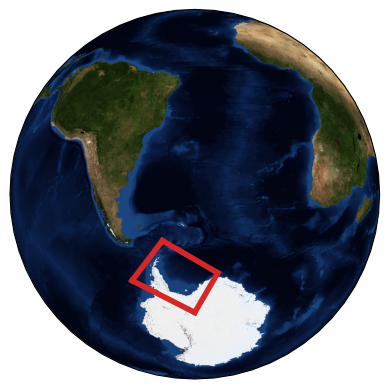

In [39]:
projection = ccrs.Orthographic(central_longitude=-30, central_latitude=-45)
plot_map(img_url, projection=projection)

fig = plt.gcf()
ax = plt.gca()

# in format lon, lat
SW = (-84, -65.2)
SE = (-30.2, -84.8)
NE = (-9.5, -69.2)
NW = (-49.5,-58.3)

edges = [(SW, SE), (SE, NE), (NE, NW), (NW, SW)]

for (lon0, lat0), (lon1, lat1) in edges:
    ax.plot([lon0, lon1],
            [lat0, lat1],
            transform=ccrs.Geodetic(),
            color="tab:red",
            linewidth=4)

plt.show()
fig.savefig("marble.svg", dpi=300)